In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("All imports done ✅")

TensorFlow: 2.21.0
All imports done ✅


In [5]:
DATASET_PATH = "chest_xray"

for split in ['train', 'test']:
    for label in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(DATASET_PATH, split, label)
        print(f"✅ {split}/{label}: {len(os.listdir(path))} images")

✅ train/NORMAL: 100 images
✅ train/PNEUMONIA: 100 images
✅ test/NORMAL: 20 images
✅ test/PNEUMONIA: 20 images


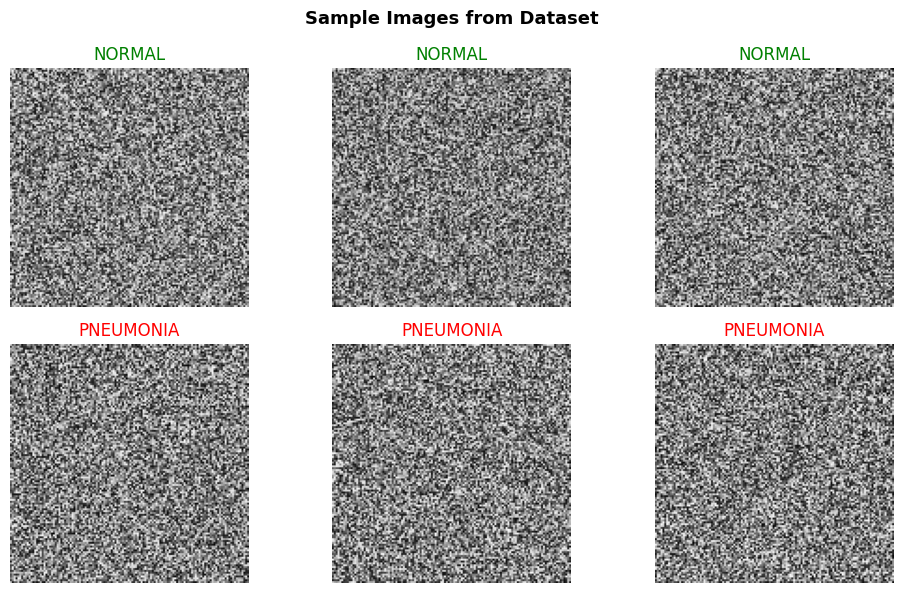

Saved ✅ outputs/sample_images.png  📸 SCREENSHOT THIS


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle('Sample Images from Dataset', fontsize=13, fontweight='bold')

for row, label in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(DATASET_PATH, 'train', label)
    files = os.listdir(folder)[:3]
    for col, fname in enumerate(files):
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(label, color='green' if label=='NORMAL' else 'red')
        axes[row][col].axis('off')

plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/sample_images.png', dpi=150)
plt.show()
print("Saved ✅ outputs/sample_images.png  📸 SCREENSHOT THIS")

In [7]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'train'),
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'train'),
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'test'),
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\nClass mapping: {train_data.class_indices}")
print("Data ready ✅")

Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
Found 40 images belonging to 2 classes.

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Data ready ✅


In [8]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
print("\nModel built ✅  📸 SCREENSHOT THIS")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 821,761 (3.13 MB)

 Trainable params: 821,761 (3.13 MB)

 Non-trainable params: 0 (0.00 B)


Model built ✅  📸 SCREENSHOT THIS


In [9]:
print("Training... (~1-2 mins)\n")

history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    verbose=1
)

os.makedirs('outputs', exist_ok=True)
model.save('outputs/medical_model.h5')
print("\nModel saved ✅  📸 SCREENSHOT THE TRAINING LOGS")

Training... (~1-2 mins)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 453ms/step - accuracy: 0.5063 - loss: 0.6490 - val_accuracy: 0.5000 - val_loss: 0.5337
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8500 - loss: 0.4258 - val_accuracy: 1.0000 - val_loss: 0.2478
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9937 - loss: 0.1526 - val_accuracy: 1.0000 - val_loss: 0.0356
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 1.0000 - loss: 0.0278 - val_accuracy: 1.0000 - val_loss: 7.2962e-04
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 6.1807e-04
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 1.1086e-04
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 1.0000 - loss: 9.2294e-04 - val_accuracy: 1.0000 - val_loss: 2.4497e-05
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 1


Model saved ✅  📸 SCREENSHOT THE TRAINING LOGS


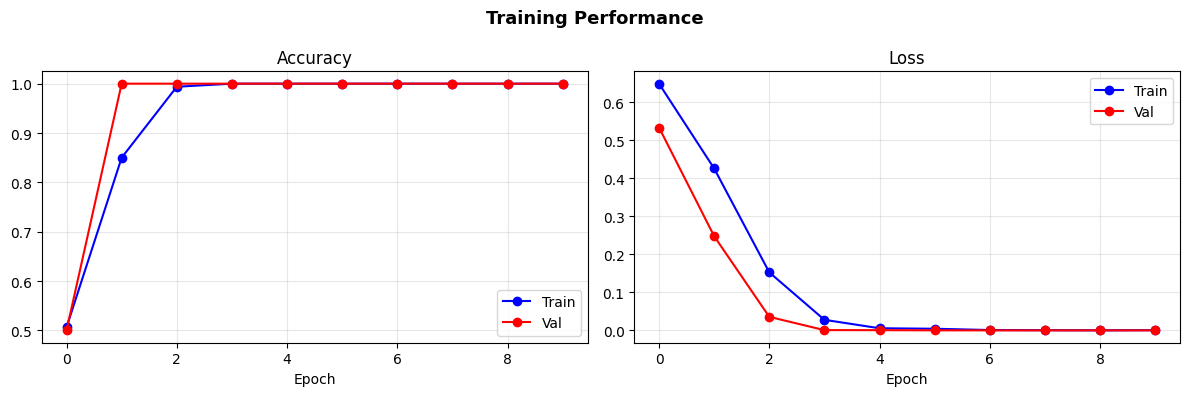

Saved ✅ outputs/training_history.png  📸 SCREENSHOT THIS


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Training Performance', fontsize=13, fontweight='bold')

axes[0].plot(history.history['accuracy'], 'b-o', label='Train')
axes[0].plot(history.history['val_accuracy'], 'r-o', label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], 'b-o', label='Train')
axes[1].plot(history.history['val_loss'], 'r-o', label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/training_history.png', dpi=150)
plt.show()
print("Saved ✅ outputs/training_history.png  📸 SCREENSHOT THIS")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step
Test Accuracy: 100.00%


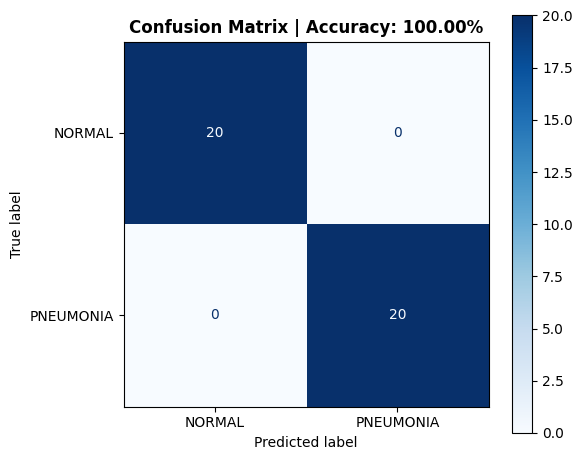

Saved ✅ outputs/confusion_matrix.png  📸 SCREENSHOT THIS


In [11]:
y_true = test_data.classes
y_pred = (model.predict(test_data) > 0.5).astype(int).flatten()

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix | Accuracy: {acc*100:.2f}%', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()
print("Saved ✅ outputs/confusion_matrix.png  📸 SCREENSHOT THIS")

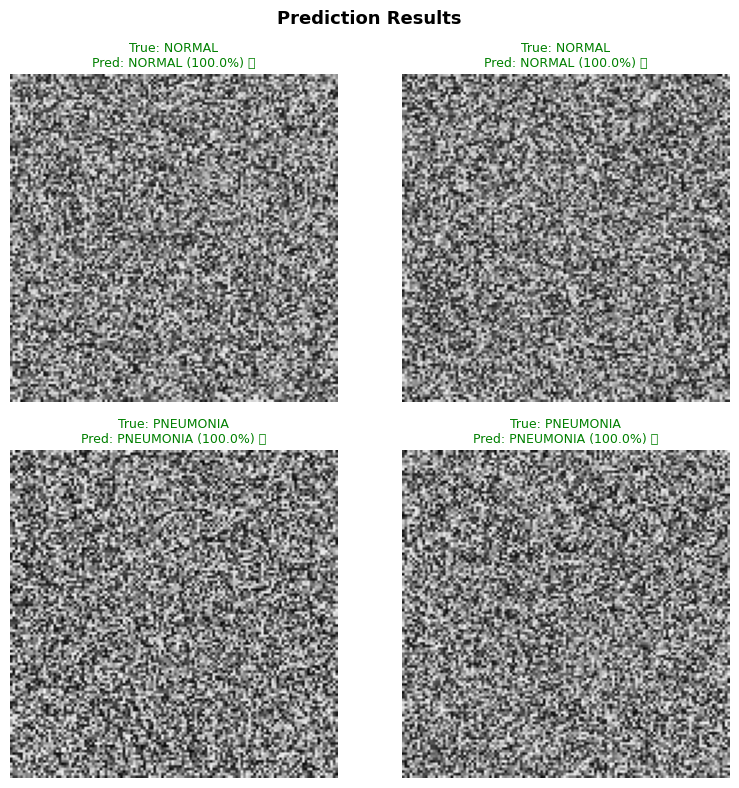

Saved ✅ outputs/predictions.png  📸 SCREENSHOT THIS


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle('Prediction Results', fontsize=13, fontweight='bold')

samples = []
for label in ['NORMAL', 'PNEUMONIA']:
    folder = os.path.join(DATASET_PATH, 'test', label)
    files = os.listdir(folder)[:2]
    for f in files:
        samples.append((os.path.join(folder, f), label))

for idx, (img_path, true_label) in enumerate(samples):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    inp = cv2.resize(img, (64,64)) / 255.0
    inp = inp.reshape(1, 64, 64, 1)
    prob = model.predict(inp, verbose=0)[0][0]
    pred = "PNEUMONIA" if prob > 0.5 else "NORMAL"
    conf = prob if prob > 0.5 else 1 - prob
    correct = "✅" if pred == true_label else "❌"

    row, col = idx // 2, idx % 2
    axes[row][col].imshow(img, cmap='gray')
    axes[row][col].set_title(
        f'True: {true_label}\nPred: {pred} ({conf*100:.1f}%) {correct}',
        color='green' if correct == '✅' else 'red', fontsize=9
    )
    axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('outputs/predictions.png', dpi=150)
plt.show()
print("Saved ✅ outputs/predictions.png  📸 SCREENSHOT THIS")

In [13]:
print("=" * 45)
print("   AI MEDICAL IMAGE ANALYSIS — COMPLETE")
print("=" * 45)
print(f"  Model      : CNN (2 Conv layers)")
print(f"  Image Size : 64x64 grayscale")
print(f"  Epochs     : 10")
print(f"  Test Acc   : {acc*100:.2f}%")
print(f"\n  Output files:")
for f in os.listdir('outputs'):
    print(f"    → {f}")
print("\n  Project done ✅")
print("=" * 45)

   AI MEDICAL IMAGE ANALYSIS — COMPLETE
  Model      : CNN (2 Conv layers)
  Image Size : 64x64 grayscale
  Epochs     : 10
  Test Acc   : 100.00%

  Output files:
    → confusion_matrix.png
    → medical_model.h5
    → predictions.png
    → sample_images.png
    → training_history.png

  Project done ✅


In [14]:
import os
print(os.getcwd())

C:\Users\Ashwini
